### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [5]:
data = pd.read_csv('data/coupons.csv')

In [6]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [29]:
print(data.shape)
data.info() 
print(data.isnull().sum().sort_values(ascending=False))
(data.isnull().mean() * 100).sort_values(ascending=False)
print("Duplicates:", data.duplicated().sum())


(12684, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12

3. Decide what to do about your missing data -- drop, replace, other...

In [31]:
data_clean = data.drop(columns=['car']).dropna()
(data.isnull().mean() * 100).sort_values(ascending=False)

car                     99.148534
CoffeeHouse              1.710817
Restaurant20To50         1.490066
CarryAway                1.190476
RestaurantLessThan20     1.024913
Bar                      0.843582
destination              0.000000
passanger                0.000000
direction_opp            0.000000
direction_same           0.000000
toCoupon_GEQ25min        0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ5min         0.000000
income                   0.000000
occupation               0.000000
education                0.000000
has_children             0.000000
maritalStatus            0.000000
age                      0.000000
gender                   0.000000
expiration               0.000000
coupon                   0.000000
time                     0.000000
temperature              0.000000
weather                  0.000000
Y                        0.000000
dtype: float64

4. What proportion of the total observations chose to accept the coupon?



In [32]:
acceptance_rate = data['Y'].mean()
print(acceptance_rate)
data['Y'].value_counts()

0.5684326710816777


Y
1    7210
0    5474
Name: count, dtype: int64

5. Use a bar plot to visualize the `coupon` column.

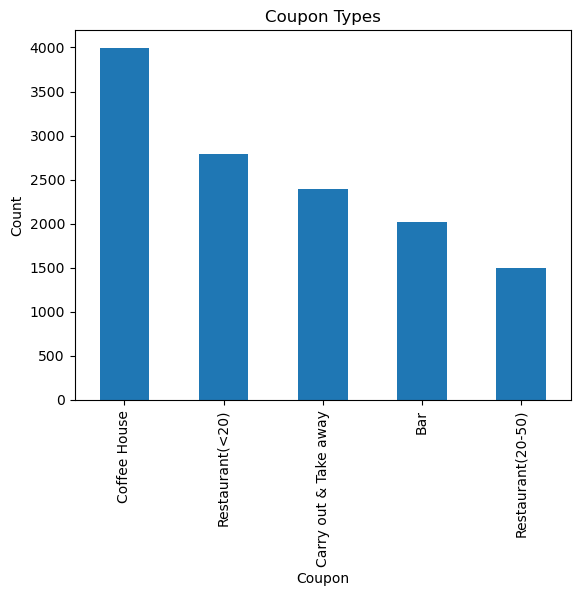

In [33]:
data['coupon'].value_counts().plot(kind='bar')
plt.title('Coupon Types')
plt.xlabel('Coupon')
plt.ylabel('Count')
plt.show()

6. Use a histogram to visualize the temperature column.

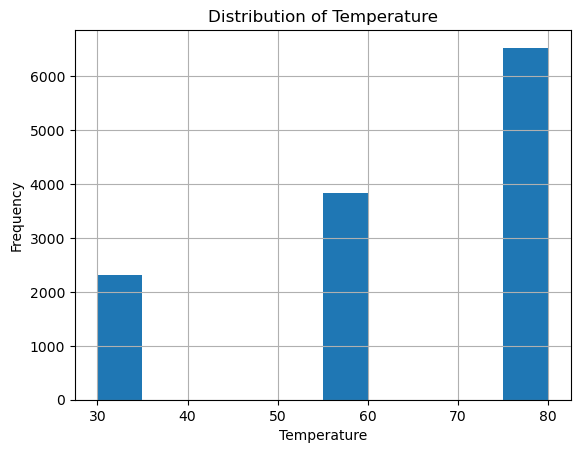

In [34]:
data['temperature'].hist()

plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [35]:
bar_df = data[data['coupon'] == 'Bar']

2. What proportion of bar coupons were accepted?


In [36]:
bar_acceptance_rate = bar_df['Y'].mean()
print(bar_acceptance_rate)

0.41001487357461575


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [39]:
bar_df['Bar'].unique()
bar_3_or_less = bar_df[bar_df['Bar'].isin(['never', 'less1', '1~3'])]
bar_more_than_3 = bar_df[bar_df['Bar'].isin(['4~8', 'gt8'])]
rate_3_or_less = bar_3_or_less['Y'].mean()
rate_more_than_3 = bar_more_than_3['Y'].mean()
print(rate_3_or_less)
print(rate_more_than_3)

0.37061769616026713
0.7688442211055276


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [40]:
condition = (
    bar_df['Bar'].isin(['1~3', '4~8', 'gt8']) &
    bar_df['age'].isin(['26', '31', '36', '41', '46', '50plus'])
)
group1 = bar_df[condition]
group2 = bar_df[~condition]
print(group1['Y'].mean())
print(group2['Y'].mean())

0.6952380952380952
0.33500313087038197


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [41]:
condition = (
    bar_df['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (bar_df['passanger'] != 'Kid(s)') &
    (bar_df['occupation'] != 'Farming Fishing & Forestry')
)

group1 = bar_df[condition]
group2 = bar_df[~condition]

rate1 = group1['Y'].mean()
rate2 = group2['Y'].mean()

print("Group 1:", rate1)
print("All others:", rate2)

Group 1: 0.7132486388384754
All others: 0.296043656207367


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [42]:
condition1 = (
    bar_df['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (bar_df['passanger'] != 'Kid(s)') &
    (bar_df['maritalStatus'] != 'Widowed')
)

condition2 = (
    bar_df['Bar'].isin(['1~3', '4~8', 'gt8']) &
    bar_df['age'].isin(['below21', '21', '26'])
)

condition3 = (
    bar_df['RestaurantLessThan20'].isin(['4~8', 'gt8']) &
    bar_df['income'].isin([
        'Less than $12500',
        '$12500 - $24999',
        '$25000 - $37499',
        '$37500 - $49999'
    ])
)

condition = condition1 | condition2 | condition3

group1 = bar_df[condition]
group2 = bar_df[~condition]

print("Group 1:", group1['Y'].mean())
print("All others:", group2['Y'].mean())

Group 1: 0.5889175257731959
All others: 0.29814665592264306


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [46]:
"""
Drivers who already visit bars frequently are much more likely to accept bar coupons. 
Acceptance also appears higher among drivers who are over 25, are not traveling with children, 
and fit some of the other lifestyle patterns examined. Overall, prior bar-going behavior 
seems to be one of the strongest indicators of whether a driver will accept a bar coupon.
"""

'\nDrivers who already visit bars frequently are much more likely to accept bar coupons. \nAcceptance also appears higher among drivers who are over 25, are not traveling with children, \nand fit some of the other lifestyle patterns examined. Overall, prior bar-going behavior \nseems to be one of the strongest indicators of whether a driver will accept a bar coupon.\n'

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [48]:
#coffee house coupon acceptance rate
coffee_df = data[data['coupon'] == 'Coffee House']
coffee_df['Y'].mean()

np.float64(0.49924924924924924)

In [49]:
#visit more than once group
more_than_once = coffee_df[
    coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])
]

#visit once or less group
once_or_less = coffee_df[
    coffee_df['CoffeeHouse'].isin(['never', 'less1'])
]

#Print out their acceptance comparison rate
print(more_than_once['Y'].mean())
print(once_or_less['Y'].mean())

0.6602497398543185
0.34615384615384615


In [50]:
#group the coupon acceptance rate by time
coffee_df.groupby('time')['Y'].mean()

time
10AM    0.640712
10PM    0.424242
2PM     0.547859
6PM     0.412626
7AM     0.445783
Name: Y, dtype: float64

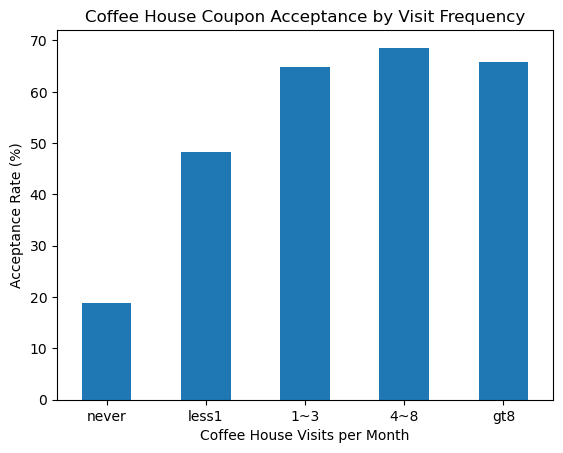

In [57]:
#Plot the graph for CoffeeHouse, X axis for visits per month, y axis acceptance rate
coffee_freq = coffee_df.groupby('CoffeeHouse')['Y'].mean() * 100

order = ['never', 'less1', '1~3', '4~8', 'gt8']
coffee_freq = coffee_freq.reindex(order)

coffee_freq.plot(kind='bar')

plt.xlabel('Coffee House Visits per Month')
plt.ylabel('Acceptance Rate (%)')
plt.title('Coffee House Coupon Acceptance by Visit Frequency')
plt.xticks(rotation=0)
plt.show()

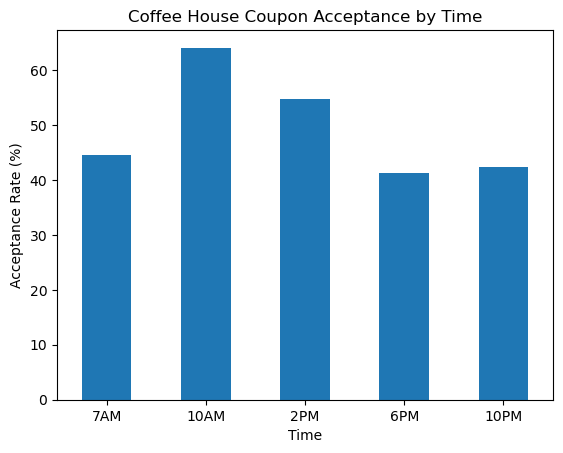

In [58]:
#Plot the graph for the day of the time acceptance rate
time_rate = coffee_df.groupby('time')['Y'].mean() * 100

order = ['7AM', '10AM', '2PM', '6PM', '10PM']

#re-arrange the time in order
time_rate = time_rate.reindex(order)

time_rate.plot(kind='bar')

plt.xlabel('Time')
plt.ylabel('Acceptance Rate (%)')
plt.title('Coffee House Coupon Acceptance by Time')
plt.xticks(rotation=0)
plt.show()

In [51]:
#group the the rate by passanger type
coffee_df.groupby('passanger')['Y'].mean()

passanger
Alone        0.437943
Friend(s)    0.596906
Kid(s)       0.483092
Partner      0.570492
Name: Y, dtype: float64

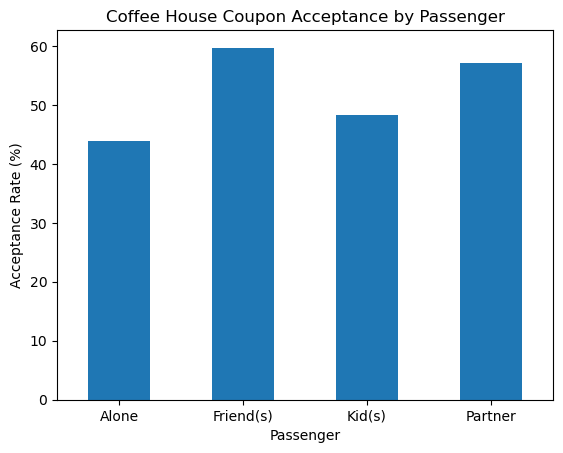

In [59]:
#plot the graph for the passanger acceptance rate
passenger_rate = coffee_df.groupby('passanger')['Y'].mean() * 100

passenger_rate.plot(kind='bar')

plt.xlabel('Passenger')
plt.ylabel('Acceptance Rate (%)')
plt.title('Coffee House Coupon Acceptance by Passenger')
plt.xticks(rotation=0)
plt.show()

In [52]:
#compare the rate between age groups under 30 vs over 30
under_30 = coffee_df[
    coffee_df['age'].isin(['below21', '21', '26'])
]

age_30_plus = coffee_df[
    ~coffee_df['age'].isin(['below21', '21', '26'])
]

print(under_30['Y'].mean())
print(age_30_plus['Y'].mean())

0.5342902711323764
0.46808510638297873


In [53]:
#Compare the rate between expiration time
coffee_df.groupby('expiration')['Y'].mean()

expiration
1d    0.583946
2h    0.431971
Name: Y, dtype: float64

In [54]:
#Combine the conditions for the people visit more than once, time during 10AM and 2PM, 
#and passanagers with friends and partners

condition = (
    coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8']) &
    coffee_df['time'].isin(['10AM', '2PM']) &
    coffee_df['passanger'].isin(['Friend(s)', 'Partner'])
)

#group 2 is the other group other than the group 1 condition above
group1 = coffee_df[condition]
group2 = coffee_df[~condition]

#Notice the group1 high acceptance rate
print("Group 1:", group1['Y'].mean())
print("All others:", group2['Y'].mean())

Group 1: 0.7884615384615384
All others: 0.45093457943925236


In [61]:
#doing the ztest and p_value test
#
from statsmodels.stats.proportion import proportions_ztest

frequent = coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])

successes = [
    coffee_df[frequent]['Y'].sum(),
    coffee_df[~frequent]['Y'].sum()
]

nobs = [
    coffee_df[frequent]['Y'].count(),
    coffee_df[~frequent]['Y'].count()
]

z_stat, p_value = proportions_ztest(successes, nobs)

#large absolute z-score & very small p-value, indicatstrong statistical evidence of a real association in the population
print(z_stat, p_value)

19.59488595060781 1.70968225039934e-85


In [ ]:
"""
-Finding for Coffee House Coupon Acceptance Rate:
1. The overall Coffee House coupon acceptance rate was approximately 49.9%. 
Prior coffee-house behavior showed the strongest relationship with acceptance. 
Drivers who visited coffee houses more than once per month accepted approximately 66.0% of coupons, 
compared with only 35.0% among those who visited once per month or less.
2. Acceptance was highest around 10 AM (64.1%) and 2 PM (54.8%), while evening acceptance was approximately 41–42%. 
Drivers traveling with friends (59.7%) or a partner (57.0%) accepted coupons more frequently than 
those traveling alone (43.8%). 
3. Coupons with a one-day expiration (58.4%) were also accepted considerably more often 
than coupons expiring in two hours (43.2%).
4. The relationship between coffee-house visit frequency and coupon acceptance was statistically significant (p<0.001). 
This suggests that prior coffee-house behavior is strongly associated with coupon acceptance,
"""

In [ ]:
"""
-Actional Items:
1. Prioritize frequent coffee-house customers. This is the strongest observed segmentation variable: 
roughly 66% acceptance versus 35% for infrequent customers.
2. Favor 10 AM and 2 PM delivery. These periods show substantially higher acceptance than evening hours.
3. Use longer expiration windows. One-day coupons perform considerably better than two-hour coupons.
4. Consider social context. Customers traveling with friends or partners show higher acceptance than 
those traveling alone.
"""

In [ ]:
"""
-Next steps and Recommendations:
The next step would be to evaluate these variables together rather than one at a time. 
A classification model could estimate which factors remain important after accounting for the others. 
It would also be useful to test interactions—for example, 
whether the advantage of a 10 AM coupon is especially strong among frequent 
coffee-house customers—and validate the findings on new data before using them for real-world targeting.
"""